In [1]:
# importación de bibliotecas
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

from sklearn.datasets import load_wine
from sklearn.feature_selection import SequentialFeatureSelector
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.linear_model import LassoCV
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_percentage_error
from statsmodels.tools.eval_measures import meanabs

import warnings
warnings.filterwarnings('ignore')

In [2]:
# carga de datos
data, target = load_wine(return_X_y= True, as_frame= True)

In [3]:
data.shape

(178, 13)

In [4]:
data.head()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0


#Selección de Variables

### 1. Forward Selection


In [5]:
# carga de datos
X1, y1 = load_wine(return_X_y= True, as_frame= True)

In [6]:
# Crear un modelo base (por ejemplo, Regresión Logística)
base_model = LogisticRegression()

# Utilizar Forward Selection para seleccionar características
sfs = SequentialFeatureSelector(base_model, n_features_to_select=7, direction='forward', scoring='accuracy', cv=5)
sfs.fit(X1, y1)
selected_features_forward = X1.columns[sfs.support_]
print("Características seleccionadas por Forward Selection:")
print(selected_features_forward)

Características seleccionadas por Forward Selection:
Index(['alcohol', 'ash', 'alcalinity_of_ash', 'total_phenols', 'flavanoids',
       'nonflavanoid_phenols', 'hue'],
      dtype='object')


### 2. Filtro por Correlaciones

In [7]:
# carga de datos y posterior concatenación
X2, y2 = load_wine(return_X_y= True, as_frame= True)
data_completa = pd.concat([X2, y2], axis =1)

In [8]:
correlaciones_pearson = data_completa.corr()

In [9]:
correlacion_Vs_target = correlaciones_pearson.loc[:, ['target']].sort_values('target', ascending=False)

<Axes: >

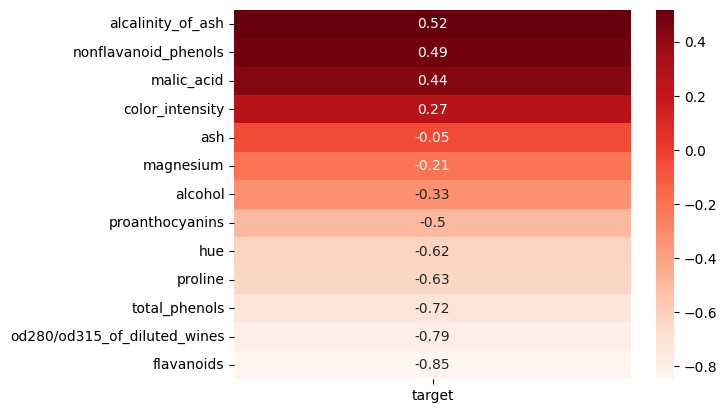

In [ ]:
#visualicemos la correlación entre las features y el target
sns.heatmap(correlacion_Vs_target.iloc[1:], cmap='Reds', annot=True)

In [10]:
# filtro por correlación
selected_features_corr = correlacion_Vs_target[abs(correlacion_Vs_target).iloc[1:]>=0.49].dropna().index
selected_features_corr

Index(['alcalinity_of_ash', 'proanthocyanins', 'hue', 'proline',
       'total_phenols', 'od280/od315_of_diluted_wines', 'flavanoids'],
      dtype='object')

### 3. Selección por Lasso

In [11]:
# carga de datos
X3, y3 = load_wine(return_X_y= True, as_frame= True)

In [12]:
# Usar LassoCV para seleccionar características
lasso_model = LassoCV(alphas=[0.001, 0.01, 0.1, 1.0])
lasso_model.fit(X3, y3)
lasso_coefs = lasso_model.coef_
selected_features_lasso = X3.columns[lasso_coefs != 0]
print("Características seleccionadas por Lasso:")
print(selected_features_lasso)

Características seleccionadas por Lasso:
Index(['alcohol', 'malic_acid', 'alcalinity_of_ash', 'flavanoids',
       'color_intensity', 'od280/od315_of_diluted_wines', 'proline'],
      dtype='object')


Comparemos las features obtenidas por los diferentes métodos de selección de variables.

In [ ]:
features = {'selected_features_forward': selected_features_forward.sort_values(),
            'selected_features_corr': selected_features_corr.sort_values(),
            'selected_features_lasso': selected_features_lasso.sort_values()}

In [ ]:
df_features = pd.DataFrame(features)
df_features

,selected_features_forward,selected_features_corr,selected_features_lasso
0,alcalinity_of_ash,alcalinity_of_ash,alcalinity_of_ash
1,alcohol,flavanoids,alcohol
2,ash,hue,color_intensity
3,flavanoids,od280/od315_of_diluted_wines,flavanoids
4,hue,proanthocyanins,malic_acid
5,nonflavanoid_phenols,proline,od280/od315_of_diluted_wines
6,total_phenols,total_phenols,proline


# Entrenamiento de un modelo empleando diferentes features obtenidas de diferentes métodos de selección de variables

Vamos a entrenar un modelo cualquiera, en este caso se optó por un modelo de regresión lineal.

La idea es entrenarlo con todas las features disponibles y con las distintas features obtenidas por los tres diferentes métodos de selección de variables que hemos visto.

Seguidamente se determinarán métricas que nos permitirán compararlos y concluir cuál es el modelo de mejor rendimiento en base a las features con las cuales se entrenó.

### 0. Entrenamiento usando todas las features

In [13]:
X0, y0 = load_wine(return_X_y= True, as_frame= True)

In [15]:
model = LinearRegression()
model.fit(X0,y0)

y_pred0 = model.predict(X0)

In [16]:
mse_all_features = mean_squared_error(y0, y_pred0)
r2_all_features = r2_score(y0, y_pred0)
mape_all_features = round(meanabs(y0, y_pred0)*100,2)

In [17]:
print('MSE usando todas las caracteristicas:', mse_all_features)
print('R2 usando todas las caracteristicas:',r2_all_features)
print('MAPE usando todas las caracteristicas:',mape_all_features)

MSE usando todas las caracteristicas: 0.059677387465844466
R2 usando todas las caracteristicas: 0.9000888589448974
MAPE usando todas las caracteristicas: 19.42


### 1. Entrenamiento usando las features obtenidas por Forward selection

In [18]:
wine = load_wine()
y1 = wine.target

In [19]:
X1 = X1[selected_features_forward]

In [20]:
model_forward = LinearRegression()
model_forward.fit(X1,y1)

LinearRegression()

In [21]:
y_pred1 = model_forward.predict(X1)

In [22]:
mse_all_forward = mean_squared_error(y1, y_pred1)
r2_all_forward = r2_score(y1, y_pred1)
mape_all_forward = round(meanabs(y1, y_pred1)*100,2)

In [ ]:
print('MSE usando las caracteristicas obtenidas por forward:', mse_all_forward)
print('R2 usando las caracteristicas obtenidas por forward:',r2_all_forward)
print('MAPE usando las caracteristicas obtenidas por forward:',mape_all_forward)

MSE usando todas las caracteristicas: 0.10601309060675122
R2 usando todas las caracteristicas: 0.8225142001170777
MAPE usando todas las caracteristicas: 25.96


###2. Entrenamiento usando las features obtenidas por filtro de correlaciones

In [23]:
wine = load_wine()
y2 = wine.target

In [24]:
X2 = X2[selected_features_corr]

In [25]:
model_corr = LinearRegression()
model_corr.fit(X2,y2)

LinearRegression()

In [26]:
y_pred2 = model_corr.predict(X2)

In [27]:
mse_all_corr = mean_squared_error(y2, y_pred2)
r2_all_corr = r2_score(y2, y_pred2)
mape_all_corr = round(meanabs(y2, y_pred2)*100,2)

In [ ]:
print('MSE usando las caracteristicas obtenidas por correlación:', mse_all_corr)
print('R2 usando las caracteristicas obtenidas por correlación:',r2_all_corr)
print('MAPE usando las caracteristicas obtenidas por correlación:',mape_all_corr)

MSE usando todas las caracteristicas: 0.071517261992432
R2 usando todas las caracteristicas: 0.8802666880333836
MAPE usando todas las caracteristicas: 21.43


###3. Entrenamiento usando las features obtenidas por Lasso

In [28]:
wine = load_wine()
y3 = wine.target

In [29]:
X3 = X3[selected_features_lasso]

In [30]:
model_lasso = LinearRegression()
model_lasso.fit(X3,y3)

LinearRegression()

In [31]:
y_pred3 = model_lasso.predict(X3)

In [32]:
mse_all_lasso = mean_squared_error(y3, y_pred3)
r2_all_lasso = r2_score(y3, y_pred3)
mape_all_lasso = round(meanabs(y3, y_pred3)*100,2)

In [ ]:
print('MSE usando las caracteristicas obtenidas por Lasso:', mse_all_lasso)
print('R2 usando las caracteristicas obtenidas por Lasso:',r2_all_lasso)
print('MAPE usando las caracteristicas obtenidas por Lasso:',mape_all_lasso)

MSE usando todas las caracteristicas: 0.0650373918882316
R2 usando todas las caracteristicas: 0.8911152060984555
MAPE usando todas las caracteristicas: 20.43


Comparemos las métricas obtenidas para los diferentes modelos de regresión lineal entrenados.

In [33]:
metrics = {'all_features':[mse_all_features, r2_all_features, mape_all_features],
    'forward':[mse_all_forward, r2_all_forward, mape_all_forward],
    'corr':[mse_all_corr, r2_all_corr, mape_all_corr],
    'lasso':[mse_all_lasso, r2_all_lasso, mape_all_lasso]}


In [34]:
df_metrics = pd.DataFrame(metrics, index=['MSE', 'R2', 'MAPE'])
df_metrics

,all_features,forward,corr,lasso
MSE,0.059677,0.106013,0.071517,0.065037
R2,0.900089,0.822514,0.880267,0.891115
MAPE,19.420000,25.960000,21.430000,20.430000
